<a href="https://colab.research.google.com/github/tcurtis714/lis4693/blob/main/lab-5/lab5_topic_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Packages

In [14]:
!pip install gensim
!pip install pyldavis
!pip install nltk

## Download English stopwords

In [15]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Import packages

In [16]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

In [17]:
import requests
import io

## TASK 1: Load dataset from github
The dataset is collection of journal articles that deal with information systems in the field of computer science.

Filters:
Publication Type = ( journal article ) Field of Study = ( Computer science ) Subject = ( Information Systems ) Has Abstract

In [26]:
url = 'https://github.com/tcurtis714/lis4693/raw/refs/heads/main/lab-5/lab5-metadata.csv'
response = requests.get(url)
response.raise_for_status()
text = response.text

In [27]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

               Lens ID                                              Title  \
0  000-266-098-698-118  Tear fluid database: a reference website for t...   
1  000-365-590-769-09X  System-Level Optimization of Crowdsensing Sens...   
2  000-549-915-673-00X  Enhancing the hypatia simulator for LEO satell...   
3  000-707-131-188-883  Principal Component Analysis Methods and Teach...   
4  000-835-078-432-723  A Dynamic Updating-Based RSSI Fingerprint Loca...   

  Date Published  Publication Year Publication Type  \
0     2026-01-15              2026  journal article   
1     2026-01-01              2026  journal article   
2     2026-01-09              2026  journal article   
3     2026-01-01              2026  journal article   
4            NaN              2026  journal article   

                                        Source Title               ISSNs  \
0  Database : the journal of biological databases...            17580463   
1                    IEEE Internet of Things Journal  

In [28]:
print(df.columns)

Index(['Lens ID', 'Title', 'Date Published', 'Publication Year',
       'Publication Type', 'Source Title', 'ISSNs', 'Publisher',
       'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number',
       'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms',
       'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI',
       'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References',
       'Citing Works Count', 'Is Open Access', 'Open Access License',
       'Open Access Colour'],
      dtype='object')


## TASK 2: Display first 10 rows of data and select the column for topic modeling

I chose the Abstract column because it contains summaries for each article

In [29]:
df = df[['Author/s', 'Abstract', 'Date Published']]

In [30]:
print(df.head(10))

                                            Author/s  \
0  Drew Mayernik; Saleh Ahmed; Eliza Williams; Ta...   
1        Boyu Pang; Junhan Fu; Ruizhi Liao; Yinyu Ye   
2  Pilar Manzanares-Lopez; Abel Lopez-Garcia; Mar...   
3                                null Xiaoling Huang   
4  Yiruo Lin; Kegen Yu; Jihong Dong; Chuangchi Ha...   
5  Janislley O. De Sousa; Bruno C. de Farias; Tha...   
6               Long The Nguyen; Zachary J. Sheffler   
7  Wendy Arianne Günther; Mayur Joshi; Panos Cons...   
8  Benjamin Knight; Dmitry Mitrofanov; Serguei Ne...   
9  Qing Fan; Liang An; Hongli Cao; Chuanqi Zhu; Y...   

                                            Abstract Date Published  
0  Tear fluid is a clinically accessible, minimal...     2026-01-15  
1  In recent years, crowdsensing has emerged as a...     2026-01-01  
2  <jats:title>Abstract</jats:title>;            ...     2026-01-09  
3  <jats:p>In the exploration of the precise teac...     2026-01-01  
4  The widespread deployment of I

In [31]:
docs = df.Abstract.tolist()
print(docs[0])

Tear fluid is a clinically accessible, minimally invasive biofluid with a complex and dynamic proteome. Molecular alterations in tear composition have been linked to a broad spectrum of ocular and systemic diseases; however, the small volume of tear samples presents substantial challenges for obtaining high-quality proteomic data. To overcome this limitation, we developed a highly sensitive mass spectrometry workflow capable of identifying more than 1,000 proteins from individual tear samples. Applying this workflow to a large and diverse cohort, we generated a representative and comprehensive profile of the human tear fluid proteome and established reference abundance ranges for proteins commonly detected in tear fluid. In parallel with protein quantification, we collected detailed clinical annotations for each participant. As the database continues to grow, these analyses will increasingly support the identification of disease-associated proteomic signatures, deepen our understanding

## TASK 3: Preprocess data, create bag-of-words, run 2 LDA models for 10 topics and 20 topics

### Cleaning documents

In [32]:
# Load stopwords
stop_words = stopwords.words('english')

In [33]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words


In [59]:
## Adding custom stopwords

custom_stopwords = ['jatssec', 'jats']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['jatssec', 'jats']


In [60]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
Tear fluid is a clinically accessible, minimally invasive biofluid with a complex and dynamic proteome. Molecular alterations in tear composition have been linked to a broad spectrum of ocular and systemic diseases; however, the small volume of tear samples presents substantial challenges for obtaining high-quality proteomic data. To overcome this limitation, we developed a highly sensitive mass spectrometry workflow capable of identifying more than 1,000 proteins from individual tear samples. Applying this workflow to a large and diverse cohort, we generated a representative and comprehensive profile of the human tear fluid proteome and established reference abundance ranges for proteins commonly detected in tear fluid. In parallel with protein quantification, we collected detailed clinical annotations for each participant. As the database continues to grow, these anal

In [61]:
# Pass all docs into clean_doc
cleaned_docs = [clean_doc(doc) for doc in docs]

### Create ID-Word index

In [62]:
id2word = corpora.Dictionary(cleaned_docs)

In [63]:
id2word[230]

'communication'

In [64]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

In [65]:
print(corpus[0])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 2), (23, 2), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 2), (36, 3), (37, 1), (38, 1), (39, 1), (40, 1), (41, 2), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 4), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 2), (87, 3), (88, 2), (89, 3), (90, 2), (91, 1), (92, 1), (93, 1), (94, 1), (95, 1), (96, 1), (97, 1), (98, 1), (99, 1), (100, 3), (101, 1), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 1), (108, 1), (109, 1), (110, 1),

In [66]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	1000
1	2134
2	74
3	abundance
4	accelerate
5	accessible
6	advancing
7	alongside
8	alterations
9	analyses
10	annotations
11	applying
12	associated
13	biofluid
14	biological
15	biology
16	biomarker
17	biomarkers
18	broad
19	broadly
20	capable
21	challenges
22	clinical
23	clinically
24	cohort
25	collected
26	commonly
27	community
28	comparative
29	complex
30	composition
31	comprehensive
32	continues
33	created
34	current
35	data
36	database
37	deepen
38	detailed
39	detected
40	developed
41	discovery
42	diseaseassociated
43	diseases
44	diverse
45	dynamic
46	encompassing
47	established
48	expandable
49	exploring
50	fluid
51	foundational
52	generated
53	grow
54	highly
55	highquality
56	however
57	httpstearfluidorg
58	human
59	identification
60	identifying
61	includes
62	increasingly
63	individual
64	invasive
65	investigations
66	large
67	limitation
68	linked
69	make
70	mass
71	measurements
72	mechanisms
73	metadata
74	minimally
75	molecular
76	obtaining
77	ocular
78	offering
79	overcome
80	

### Creating LDA topic models

In [67]:
lda_model1 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
lda_model2 = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)

### Analyze first model

In [68]:
topics1 = lda_model1.get_document_topics(corpus)
len(topics1)

1000

In [99]:
for topic_id, score in topics1[0]:
    print(f"({topic_id}, {float(score)})")

(0, 0.7704154849052429)
(5, 0.07175282388925552)
(6, 0.15320931375026703)


In [70]:
print(docs[0])

Tear fluid is a clinically accessible, minimally invasive biofluid with a complex and dynamic proteome. Molecular alterations in tear composition have been linked to a broad spectrum of ocular and systemic diseases; however, the small volume of tear samples presents substantial challenges for obtaining high-quality proteomic data. To overcome this limitation, we developed a highly sensitive mass spectrometry workflow capable of identifying more than 1,000 proteins from individual tear samples. Applying this workflow to a large and diverse cohort, we generated a representative and comprehensive profile of the human tear fluid proteome and established reference abundance ranges for proteins commonly detected in tear fluid. In parallel with protein quantification, we collected detailed clinical annotations for each participant. As the database continues to grow, these analyses will increasingly support the identification of disease-associated proteomic signatures, deepen our understanding

In [104]:
for topic in topics1[0]:
    terms = lda_model1.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(0, 0.7695119976997375)
35 data
174 model
158 framework
385 system
177 network

(5, 0.07368031144142151)
174 model
35 data
177 network
165 information
325 analysis

(6, 0.15218527615070343)
35 data
435 learning
188 proposed
174 model
286 performance



### Analyze second model

In [72]:
topics2 = lda_model2.get_document_topics(corpus)
len(topics2)

1000

In [103]:
for topic in topics2[0]:
    terms = lda_model2.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(4, 0.7621276378631592)
35 data
174 model
385 system
172 method
286 performance

(10, 0.23193764686584473)
188 proposed
174 model
35 data
158 framework
435 learning



I'm choosing the second model. Although both models include similar topic words, the second model creates less topics so it is easier to interpret.

## TASK 4: Visualize the second model

In [101]:
topic_data = []
target_topic_ids = [2, 5, 10, 15]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model2.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID      Word  Probability
0         2     model     0.006086
1         2      data     0.005224
2         2    system     0.003900
3         2  learning     0.003401
4         2  security     0.003230


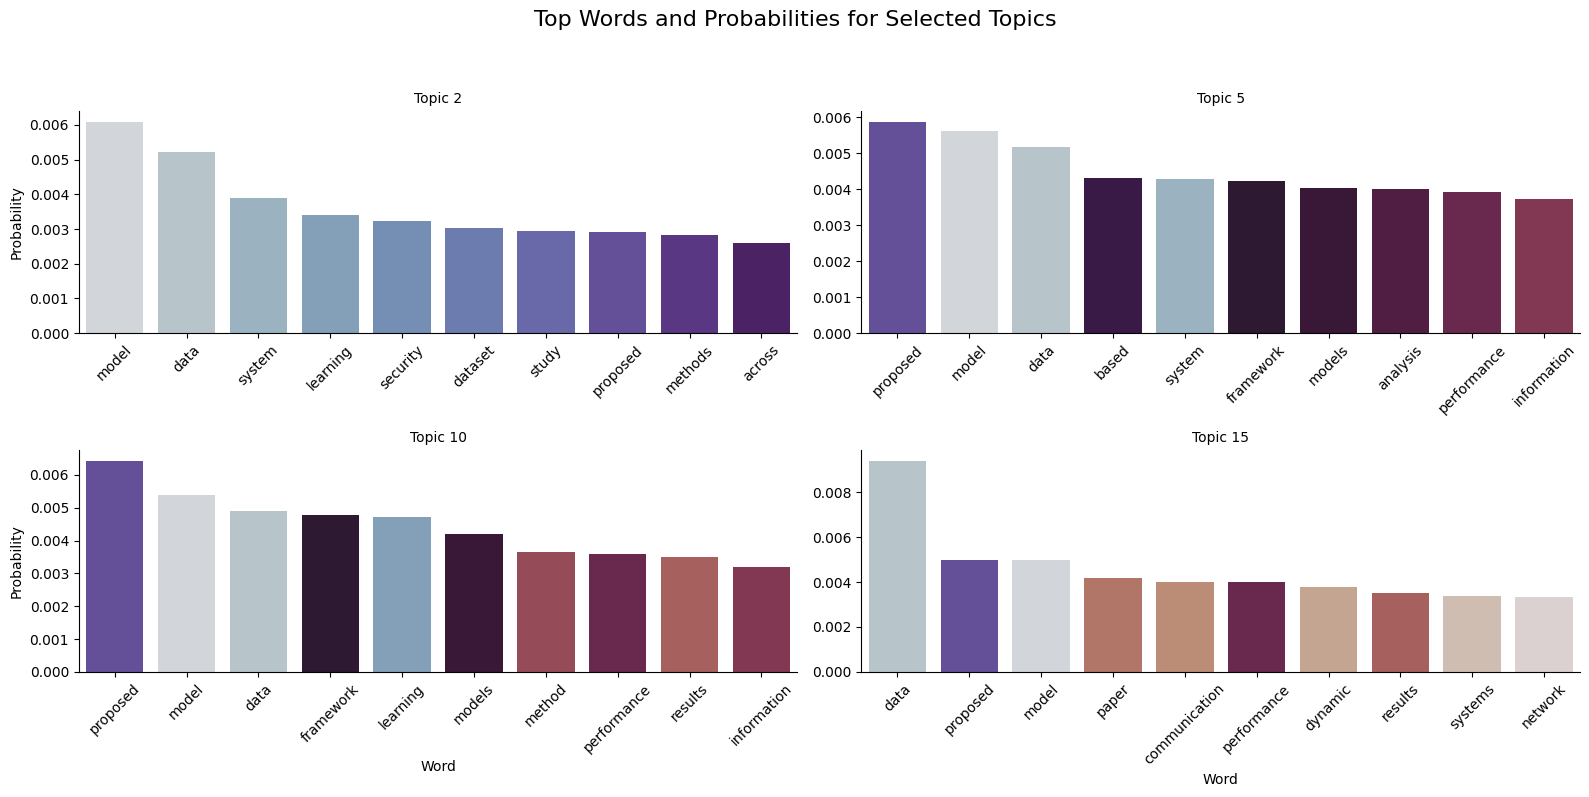

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## TASK 5: Reflection

I did not have anything go wrong or have any challenges. One day, plan to study cybersecurity. Topic modeling could help in that field with analyzing large numbers incident reports an activity logs. This will help with recognizing and preventing future security threats.